In [7]:
import utils
import keras
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

In [8]:
other = 'Other car'

In [9]:
columns = ("gate1", "gate2", "lighting")
(train_x, train_y), (val_x, val_y), (test_x, test_y) = utils.read_stratified_data(columns=columns, strata_threshold=38)
xs = [train_x, val_x, test_x]
ys = [train_y, val_y, test_y]

/Users/jorosberg/Documents/dat191/visual-vehicle-recognition-varying-lighting-conditions/datasett/kisspng-2018-tesla-model-s-tesla-motors-car-ele_fLj30kA.2230115115224762368998.png
/Users/jorosberg/Documents/dat191/visual-vehicle-recognition-varying-lighting-conditions/datasett/black-tesla-model-x-carbon-fiber-spoiler-mx22-forged-aftermarket-wheel_tCrLNla.jpg
/Users/jorosberg/Documents/dat191/visual-vehicle-recognition-varying-lighting-conditions/datasett/Edmu_EmY1CYe.-2020-Tesla-Model-Ywire-38540856-1611748943-973_634x3962-1280x720.jpg
/Users/jorosberg/Documents/dat191/visual-vehicle-recognition-varying-lighting-conditions/datasett/275815406_Andrew-Crowley-1_trans_NvBQzQNjv4BqJgZjG4XE8BZGTSy9SLp5TPzOL_bEerq8T.jpg


In [10]:
print(train_x.shape)
print(train_y.shape)
print(val_x.shape)
print(val_y.shape)
print(test_x.shape)
print(test_y.shape)

(3058, 300, 300, 3)
(3058, 6)
(638, 300, 300, 3)
(638, 6)
(639, 300, 300, 3)
(639, 6)


In [11]:
columns = ['model', 'lighting']


strata_train = train_y[list(columns)]\
    .fillna('')\
    .astype(str)\
    .agg('-'.join, axis=1).value_counts().sort_values()

strata_val = val_y[list(columns)]\
    .fillna('')\
    .astype(str)\
    .agg('-'.join, axis=1).value_counts().sort_values()

strata_test = test_y[list(columns)]\
    .fillna('')\
    .astype(str)\
    .agg('-'.join, axis=1).value_counts().sort_values()

comparison = pd.DataFrame({
    'treningssett': strata_train,
    'valideringssett': strata_val,
    'testsett': strata_test
})

comparison = comparison.fillna(0).astype(int)

comparison = comparison.sort_values(by='testsett')

print(comparison)

                    treningssett  valideringssett  testsett
S 2012–2015-Medium            11                0         0
X-Medium                      25                0         0
S 2016–nå-Medium              17                0         0
S 2012–2015-Dark               9                0         0
S 2016–nå-Dark                15                0         0
X-Dark                        30                7         6
Y 2025-nå-Light               46               10        10
3 2024–nå-Dark                55               12        12
3 2024–nå-Medium              54               12        12
3 2024–nå-Light               63               13        13
Other car-Medium              58               13        13
S 2012–2015-Light             62               13        13
Other car-Dark                67               14        14
3 2017–2023-Dark              72               16        15
3 2017–2023-Medium            69               15        15
S 2016–nå-Light               71        

In [12]:
columns = ['model']

train_key = train_y[list(columns)].fillna('').astype(str).agg('-'.join, axis=1)
test_key = test_y[list(columns)].fillna('').astype(str).agg('-'.join, axis=1)

train_lighting = pd.crosstab(train_key, train_y['lighting'])
test_lighting = pd.crosstab(test_key, test_y['lighting'])

desired_order = ['Light', 'Medium', 'Dark']

all_indices = sorted(set(train_lighting.index) | set(test_lighting.index))
comparison = pd.DataFrame(index=all_indices)

for light in desired_order:
    tr_val = train_lighting[light] if light in train_lighting.columns else pd.Series(0, index=comparison.index)
    te_val = test_lighting[light] if light in test_lighting.columns else pd.Series(0, index=comparison.index)

    tr = tr_val.reindex(comparison.index, fill_value=0)
    te = te_val.reindex(comparison.index, fill_value=0)
    
    comparison[light] = tr.astype(str) + "/" + te.astype(str)

print(comparison)

                Light  Medium    Dark
3 2017–2023    100/21   69/15   72/15
3 2024–nå       63/13   54/12   55/12
Other car    1312/282   58/13   67/14
S 2012–2015     62/13    11/0     9/0
S 2016–nå       71/15    17/0    15/0
X              140/30    25/0    30/6
Y 2020–2024    273/58  163/35  164/35
Y 2025-nå       46/10   96/21   86/19


In [13]:
i = 0

gate1                 0
gate2               5.0
color                 6
lighting         Medium
source         internal
model       Y 2020–2024
Name: 1585, dtype: object


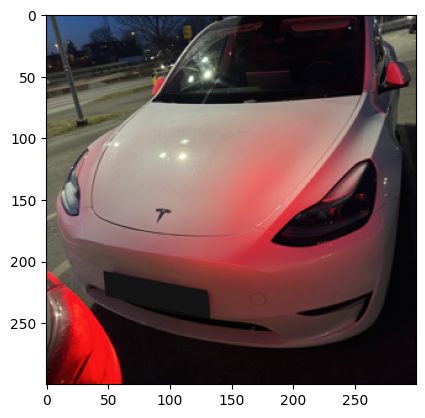

In [20]:
print(train_y.iloc[i])
plt.imshow(train_x[i])
plt.show()
i += 1

In [51]:
train_y_new = train_y["model"]
val_y_new = val_y["model"]
test_y_new = test_y["model"]
def t(x):
    if x == 'Other car':
        return 1
    return 0

vt = np.vectorize(t)

train_y_new = vt(train_y_new)
val_y_new = vt(val_y_new)
test_y_new = vt(test_y_new)

def make_model(input_shape, num_classes):
    inputs = keras.Input(shape=input_shape)
    x = keras.layers.Conv2D(64, kernel_size=(3, 3), activation="relu")(inputs)
    x = keras.layers.MaxPooling2D(pool_size=(2, 2))(x)
    x = keras.layers.Conv2D(64, kernel_size=(3, 3), activation="relu")(x)
    x = keras.layers.MaxPooling2D(pool_size=(2, 2))(x)
    x = keras.layers.Flatten()(x)
    x = keras.layers.Dropout(0.4)(x)
    outputs = keras.layers.Dense(num_classes, activation="sigmoid")(x)
    return keras.Model(inputs, outputs) 

functional_model = make_model(train_x[0].shape, 1)

epochs = 5

functional_model.compile(
    optimizer=keras.optimizers.Adam(3e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

functional_model.fit(
    train_x,
    train_y_new,
    epochs=epochs,
    validation_data=(val_x, val_y_new)
)

2026-02-26 11:44:28.505979: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M3
2026-02-26 11:44:28.506611: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 8.00 GB
2026-02-26 11:44:28.507136: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 2.67 GB
2026-02-26 11:44:28.507611: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:306] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-02-26 11:44:28.508263: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:272] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


KeyboardInterrupt: 

In [1]:
functional_model.evaluate(test_x, test_y_new)

NameError: name 'functional_model' is not defined

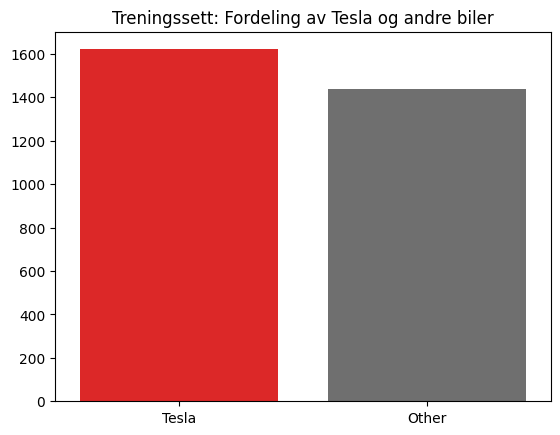

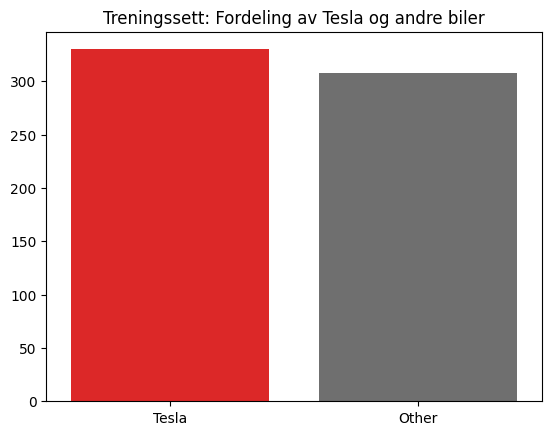

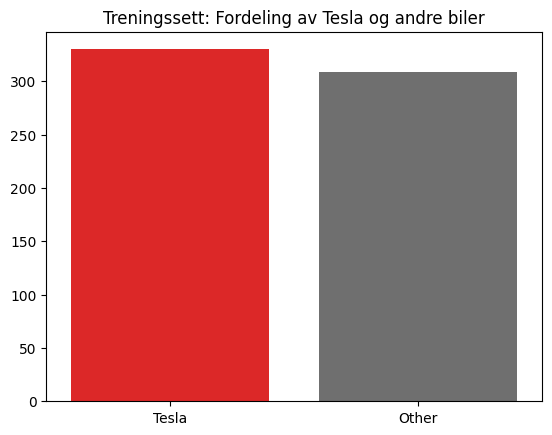

In [21]:
for df in ys:
    other = 'Other car'

    names = ['Tesla', 'Other']
    counts = [len(df[df['model'] != other]), len(df[df['model'] == other])]

    plot = sns.barplot(x=names, y=counts, hue=names, palette=["#fa0a0a", "#6f6f6f"], legend=False)
    plot.set_title(f'Treningssett: Fordeling av Tesla og andre biler')
    plt.show()  



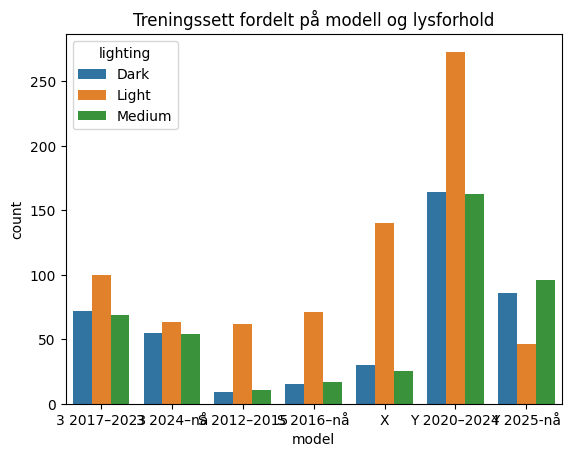

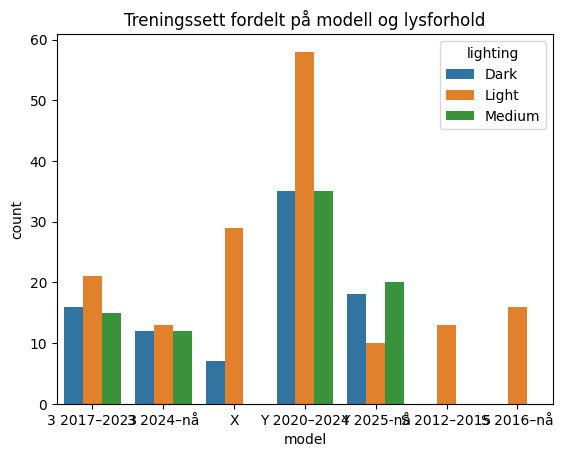

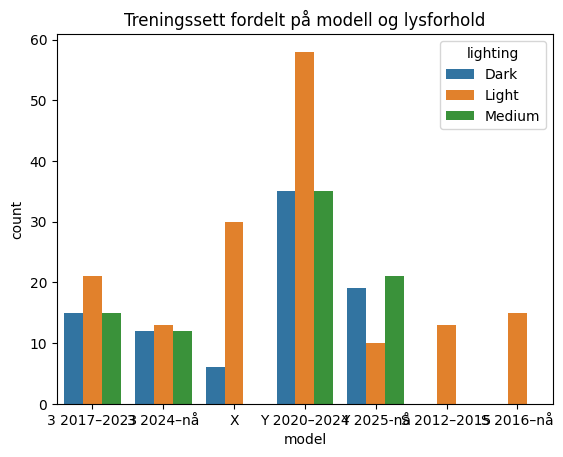

In [22]:
for df in ys:
    other = 'Other car'
    tesla = df[df['model'] != other].sort_values(by="model").sort_values(by="lighting", kind='stable')

    sns.countplot(data=tesla, x="model", hue="lighting").set_title("Treningssett fordelt på modell og lysforhold")
    plt.show()



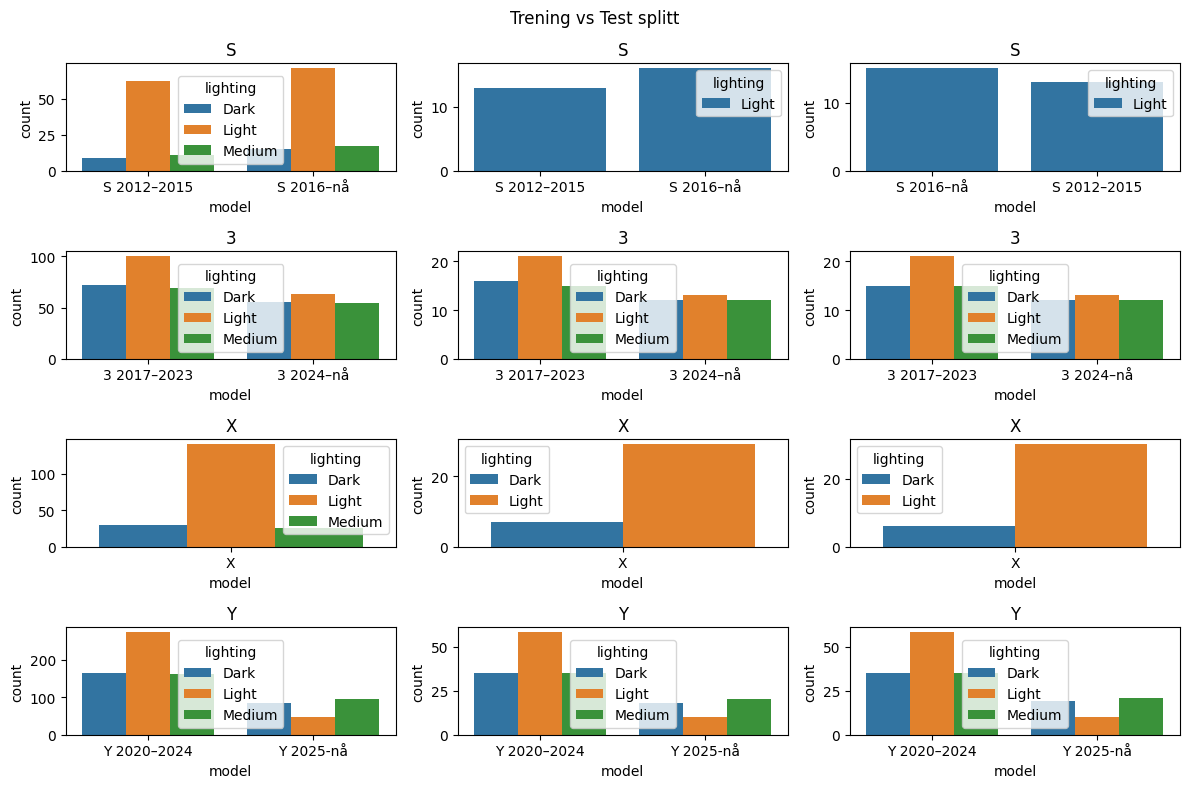

In [24]:
train_y_split = [
    train_y[train_y['model'].str.contains('S')].sort_values('lighting').sort_values('model', kind='stable'),
    train_y[train_y['model'].str.contains('3')].sort_values('lighting').sort_values('model', kind='stable'),
    train_y[train_y['model'].str.contains('X')].sort_values('lighting').sort_values('model', kind='stable'),
    train_y[train_y['model'].str.contains('Y')].sort_values('lighting').sort_values('model', kind='stable')
]

val_y_split =[
    val_y[val_y['model'].str.contains('S')].sort_values('lighting').sort_values('model', kind='stable'),
    val_y[val_y['model'].str.contains('3')].sort_values('lighting').sort_values('model', kind='stable'),
    val_y[val_y['model'].str.contains('X')].sort_values('lighting').sort_values('model', kind='stable'),
    val_y[val_y['model'].str.contains('Y')].sort_values('lighting').sort_values('model', kind='stable')
]

test_y_split = [
    test_y[test_y['model'].str.contains('S')].sort_values('lighting').sort_values('lighting', kind='stable'),
    test_y[test_y['model'].str.contains('3')].sort_values('lighting').sort_values('lighting', kind='stable'),
    test_y[test_y['model'].str.contains('X')].sort_values('lighting').sort_values('lighting', kind='stable'),
    test_y[test_y['model'].str.contains('Y')].sort_values('lighting').sort_values('lighting', kind='stable')
]

models = ["S", "3", "X", "Y"]
fig, axes = plt.subplots(4, 3, figsize=(12, 8))
fig.suptitle(f'Trening vs Test splitt')
for i in range(0,2):
    for j in range(0,2):
        sns.countplot(x='model', data=train_y_split[i*2 + j], ax=axes[i*2+j,0], hue='lighting')
        axes[i*2+j,0].title.set_text(models[i*2 + j])
        sns.countplot(x='model', data=val_y_split[i*2 + j], ax=axes[i*2+j,1], hue='lighting')
        axes[i*2+j,1].title.set_text(models[i*2 + j])
        sns.countplot(x='model', data=test_y_split[i*2 + j], ax=axes[i*2+j,2], hue='lighting')
        axes[i*2+j,2].title.set_text(models[i*2 + j])

plt.tight_layout()
plt.show()

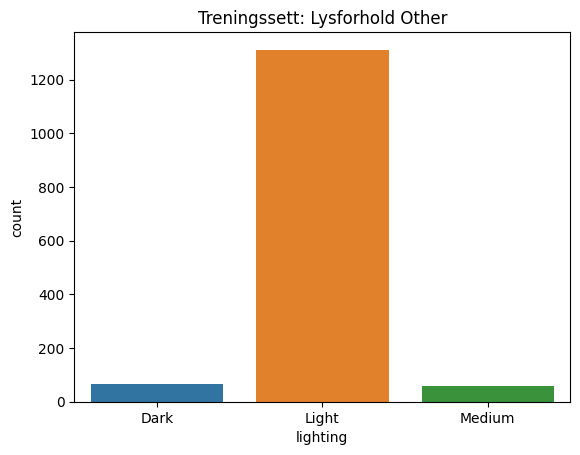

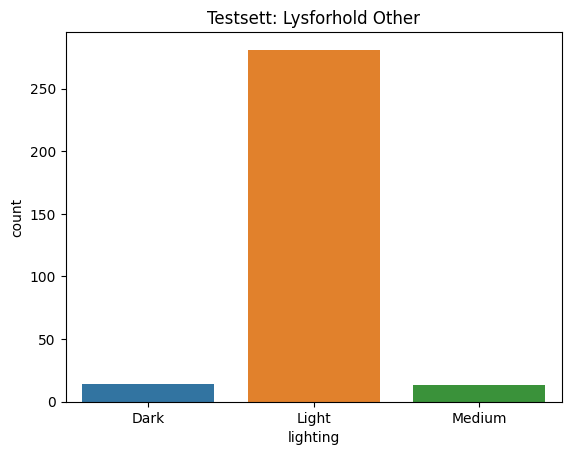

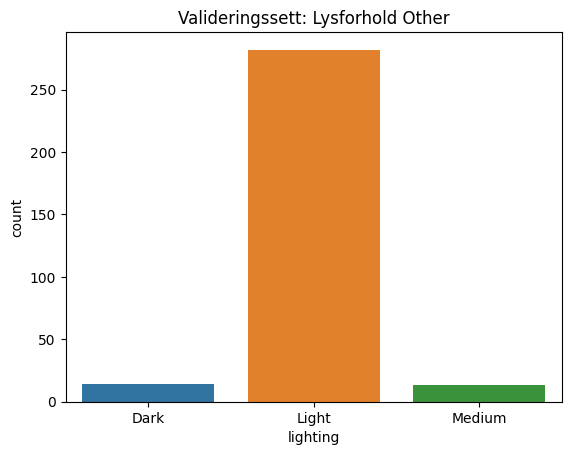

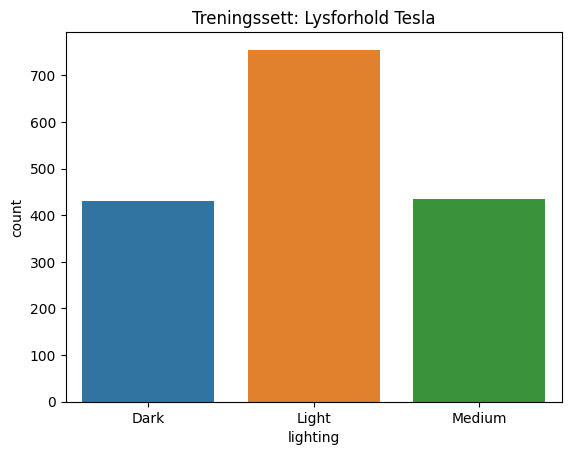

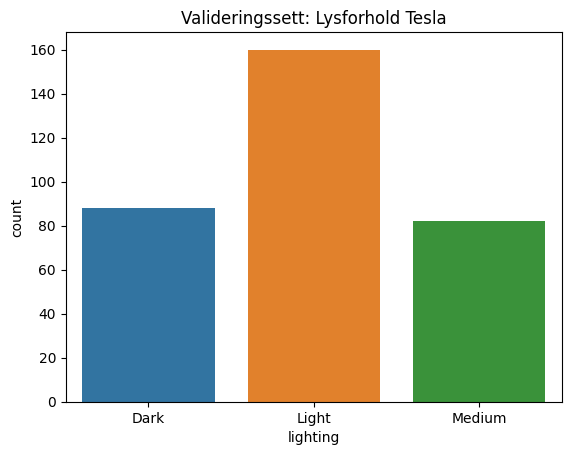

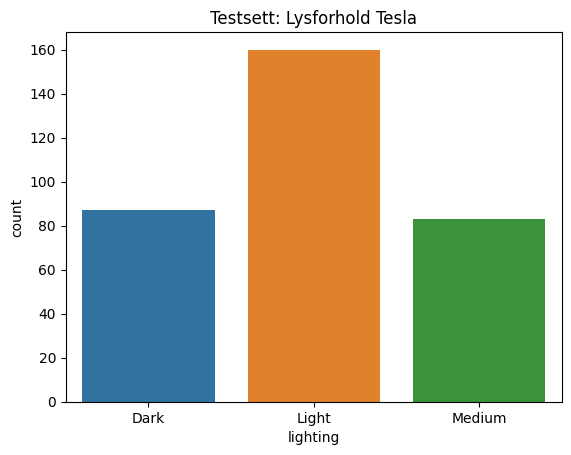

In [25]:
df = train_y[train_y["model"] == other].sort_values(by="lighting")
plot = sns.countplot(data=df, x='lighting', hue='lighting')
plot.set_title(f'Treningssett: Lysforhold Other')
plt.show()

df = val_y[val_y["model"] == other].sort_values(by="lighting")
plot = sns.countplot(data=df, x='lighting', hue='lighting')
plot.set_title(f'Testsett: Lysforhold Other')
plt.show()

df = test_y[test_y["model"] == other].sort_values(by="lighting")
plot = sns.countplot(data=df, x='lighting', hue='lighting')
plot.set_title(f'Valideringssett: Lysforhold Other')
plt.show()

df = train_y[train_y["model"] != other].sort_values(by="lighting")
plot = sns.countplot(data=df, x='lighting', hue='lighting')
plot.set_title(f'Treningssett: Lysforhold Tesla')
plt.show()

df = val_y[val_y["model"] != other].sort_values(by="lighting")
plot = sns.countplot(data=df, x='lighting', hue='lighting')
plot.set_title(f'Valideringssett: Lysforhold Tesla')
plt.show()

df = test_y[test_y["model"] != other].sort_values(by="lighting")
plot = sns.countplot(data=df, x='lighting', hue='lighting')
plot.set_title(f'Testsett: Lysforhold Tesla')
plt.show()

